# Credit Protfolio Risk Intelligence
## PACE: Plan

### Problem Statement
Retail banks face growing pressure to monitor credit portfolio health proactively, yet most risk teams rely on periodic manual reporting that obscures emarging deterioration until losses are already materialising. 
This project delivers an on-demand credit portfolio intelligence tool - a risk-tiered scorecard and default probability model, Credit Risk Portfolio Management teams to identify concentrated risk and flag high-PD segments before losses are realised.

### Primary Stakeholders 
- Credit Risk Analyst - needs repeatable default probability view by tier
- Portfolio Risk Manager - needs unified health view across products/geography
- Chief Risk Officer - needs trusted singal view for capital allocation decisions
- Compliance Teams - needs audit ready outputs aligned to Basel III

### Success Metrics
- % of loan portfolio covered by risk tier classification
- Share of Red-tier loans as % of total book
- Time to identify a deteriorating segment
- Volatility of risk tier migration (month over month)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv('../data/accepted_2007_to_2018Q4.csv',
                 low_memory=False,
                 nrows=50000
                 )
print(f"Shape:{df.shape}")
print(f"Rows:{df.shape[0]:,}")
print(f"Columns:{df.shape[1]}")
print(df.head())

Shape:(50000, 151)
Rows:50,000
Columns:151
         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN    3600.00      3600.00          3600.00   36 months   
1  68355089        NaN   24700.00     24700.00         24700.00   36 months   
2  68341763        NaN   20000.00     20000.00         20000.00   60 months   
3  66310712        NaN   35000.00     35000.00         35000.00   60 months   
4  68476807        NaN   10400.00     10400.00         10400.00   60 months   

   int_rate  installment grade sub_grade                    emp_title  \
0     13.99       123.03     C        C4                      leadman   
1     11.99       820.28     C        C1                     Engineer   
2     10.78       432.66     B        B4                 truck driver   
3     14.85       829.90     C        C5  Information Systems Officer   
4     22.45       289.91     F        F1          Contract Specialist   

  emp_length home_ownership  annual_inc ver

## PACE: Analyse - Step 1
### What does default look like in this dataset?

Before any modelling, we need to define what "default" means. The loan_status column is out traget variable. We need to understand every category it contains and make a deliberate business decision about which one constitutes a default event.

In [27]:
# Explore the target variable

print("Loan Status Distribution:")
print("="*40)
print(df['loan_status'].value_counts())
print(f"\n Total unique statuses:{df['loan_status'].nunique()}" )
print(f"\n As percentage of portfolio:")
print((df['loan_status'].value_counts(normalize=True)*100).round(2))

Loan Status Distribution:
loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64

 Total unique statuses:7

 As percentage of portfolio:
loan_status
Fully Paid           69.96
Charged Off          18.05
Current              11.22
Late (31-120 days)    0.49
In Grace Period       0.20
Late (16-30 days)     0.08
Default               0.00
Name: proportion, dtype: float64


### Default Definition Decision

Binary target variable defined as follows:
- 1 = Default: Charged off, Default
- 0 = Non-default: Fully Paid
- Excluded: Current, Late, In Grace Period (outcome uncertain - preserve label integrity)

In [28]:
default_map = {'Fully Paid':0,
              'Charged Off':1,
              'Default':1
              }

# Filter to decisive statuses only

df_clean = df[df['loan_status'].isin(default_map.keys())].copy()

# Create binary target

df_clean['default'] = df_clean['loan_status'].map(default_map)

# Confirm

print("Dataset after filtering:")
print(f"Rows retained: {len(df_clean):,}")
print(f"Rows dropped: {len(df) - len(df_clean):,}")
print(f"\n Target variable distribution:")
print(df_clean['default'].value_counts())
print(f"\n Default rate: {df_clean['default'].mean()*100:.1f}%")

Dataset after filtering:
Rows retained: 44,006
Rows dropped: 5,994

 Target variable distribution:
default
0    34978
1     9028
Name: count, dtype: int64

 Default rate: 20.5%


### Step 2 - Column Profiling

Understanding the 151 columns before selecting features.
Key questions:
- What data types do we have?
- Which columns have significant missing data?
- Which columns are candidates of our model?

In [29]:
# Column type overview:

print("Data types summary:")
print(df_clean.dtypes.value_counts())
print(f"\n Total columns: {df_clean.shape[1]}")

# Separate numerical and categorical columns

numerical_cols = df_clean.select_dtypes(include = [np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include = ['object']).columns.tolist()

print(f"\n Numerical columns: {len(numerical_cols)}")
print(f"\n categorical columns: {len(categorical_cols)}")

Data types summary:
float64    114
object      36
int64        2
Name: count, dtype: int64

 Total columns: 152

 Numerical columns: 116

 categorical columns: 36


### Step 3 - Missing Data Analysis

Columns with excessive missing data cannot contribute a reliable signal.
Threshold decision: To drop the columns missing more than 30% of values.

In [30]:
# Calculate missing data for df_clean

missing = df_clean.isnull().sum()
missing_pct = (missing/len(df_clean)*100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count>0').sort_values('missing_pct',ascending=False)

print(f"\n Total columns with missing data: {len(missing_df)}")
print(f"\n Columns missing more than 30%:")
high_missing = missing_df[missing_df['missing_pct']>30]
print(f"Count:{len(high_missing)}")
print(high_missing.head(20))
print(f"\n Columns missing 1-30%:")
low_missing = missing_df[missing_df['missing_pct'].between(1,30)]
print(f"Count: {len(low_missing)}")


 Total columns with missing data: 72

 Columns missing more than 30%:
Count:58
                                            missing_count  missing_pct
member_id                                           44006       100.00
revol_bal_joint                                     44006       100.00
sec_app_fico_range_high                             44006       100.00
sec_app_earliest_cr_line                            44006       100.00
sec_app_inq_last_6mths                              44006       100.00
sec_app_mort_acc                                    44006       100.00
sec_app_open_acc                                    44006       100.00
sec_app_revol_util                                  44006       100.00
sec_app_open_act_il                                 44006       100.00
sec_app_num_rev_accts                               44006       100.00
sec_app_chargeoff_within_12_mths                    44006       100.00
sec_app_collections_12_mths_ex_med                  44006       100.

### Step 4 - Drop High Missing Columns

Dropping 58 columns with >30% missing values.
Rationale: Insufficient data points to contribute reliable signal.
Includes: Joint application fields (structurally empty for individual loans), member_id (removed by LendingClub for privacy), free-text description fields.

In [31]:
cols_to_drop = missing_df[missing_df['missing_pct']>30].index.tolist()
print(f"Columns to drop:{len(cols_to_drop)}")

df_clean = df_clean.drop(columns = cols_to_drop)
print(f"Columns remaining:{df_clean.shape[1]}")
print(f"Shape after drop: {df_clean.shape}")

Columns to drop:58
Columns remaining:94
Shape after drop: (44006, 94)


### Step 5 - Remove Leakage and redundant columns

Target leakage: Post-orientation columns that only exist after the loan outcome is known. Including these wouold cause the model to learn from the future - valid in training, useless in production.

Redundant: duplicate columns carrying the same information.

In [32]:
# Post-origination leakage columns

leakage_cols = [
    'total_pymnt','total_pymnt_inv','total_rec_prncp','total_rec_int',
    'total_rec_late_fee','recoveries','collection_recovery_fee',
    'last_pymnt_d','last_pymnt_amnt', 'next_pyment_d', 'last_credit_pull_d',
    'out_prncp','out_prncp_inv'
]

# Redundant columns

redundant_cols = [
    'funded_amnt', # mirrored by funded_amnt
    'loan_status', #replaced by binary default column
    'id', # unique identifier, not predictive
    'url', # lendingclub url, not predictive
    'title' # free text
    ]

    # Combine and drop only columns that exist in df_clean

cols_to_remove =[
        col for col in leakage_cols + redundant_cols if col in df_clean.columns
        ]
df_clean = df_clean.drop(columns = cols_to_remove)

print(f"Leakage columns removed: {len(leakage_cols)}")
print(f"Redundant columns removed: {len(redundant_cols)}")
print(f"Columns remaining: {df_clean.shape[1]}")
print(f"Shape: {df_clean.shape}")


Leakage columns removed: 13
Redundant columns removed: 5
Columns remaining: 77
Shape: (44006, 77)


### Step 6 - EDA

Business question 1: Which loan grades carry the highest default rates?

Loan grade is LendingClub's own risk assessment:
- A : Lowest risk, to
- G : Highest risk

If our default rate tracks grade correctly, it validates the target variable and gives us our first risk segment insight.

Default rate by Loan grade:
----------------------------------------
grade  total_loans  default  default_rate
    A         8413      444          5.30
    B        13891     1916         13.80
    C        12225     2873         23.50
    D         5682     2002         35.20
    E         2774     1247         45.00
    F          830      438         52.80
    G          191      108         56.50


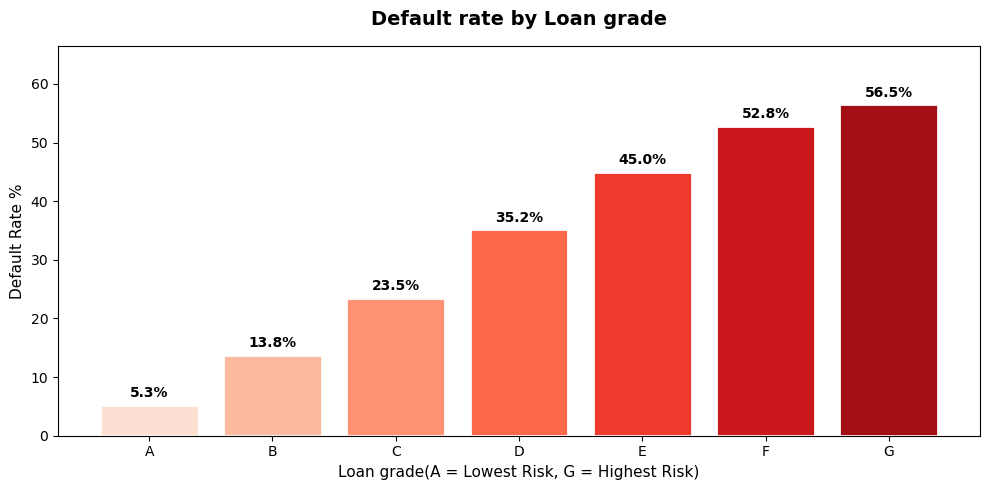


Chart saved to data folder


In [33]:
# Default rate by loan grade

grade_analysis = df_clean.groupby('grade')['default'].agg(total_loans = 'count', default ='sum').reset_index()

grade_analysis['default_rate'] = (grade_analysis['default']/grade_analysis['total_loans']*100).round(1)

grade_analysis = grade_analysis.sort_values('grade')

print("Default rate by Loan grade:")
print("-"*40)
print(grade_analysis.to_string(index=False))

# Visualise

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(
    grade_analysis['grade'],
    grade_analysis['default_rate'],
    color = sns.color_palette('Reds', n_colors=len(grade_analysis)),
    edgecolor = 'white',
    linewidth = 2
)

ax.set_title('Default rate by Loan grade', fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_xlabel('Loan grade(A = Lowest Risk, G = Highest Risk)',fontsize = 11)
ax.set_ylabel('Default Rate %', fontsize = 11)
ax.set_ylim(0,grade_analysis['default_rate'].max() + 10)

# Add value labels on bars

for bar, rate in zip(bars, grade_analysis['default_rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{rate}%',
        ha = 'center',
        va = 'bottom',
        fontsize = 10, 
        fontweight = 'bold'
    )

plt.tight_layout()
plt.savefig('../data/default_rate_by_grade.png', dpi = 300, bbox_inches = 'tight')
plt.show()

print("\nChart saved to data folder")

### Business question 2 - Interest rate vs Default Rate

Interest rate is bank's own price signal for risk. Higher rates should reflect higher perceived risk at origination. Does the actual default rate track the bank's own pricing?

Default rate by Interest rate band: 
----------------------------------------
int_rate_band  total_loans  defaults  default_rate
         0-8%         8433       444          5.30
        8-12%        16378      2421         14.80
       12-16%        11308      2828         25.00
       16-20%         6457      2594         40.20
         >20%         1430       741         51.80


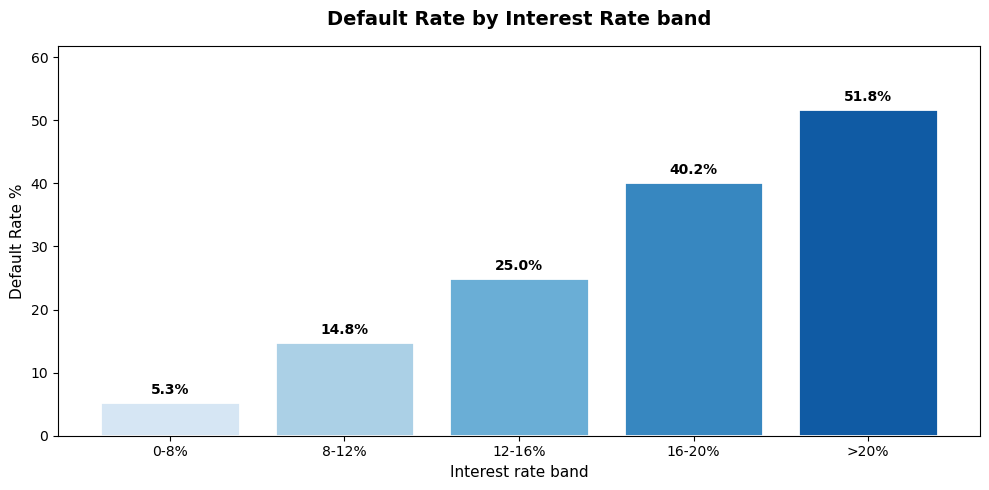

In [34]:
# Interest rate band creation

df_clean['int_rate_band'] = pd.cut(
    df_clean['int_rate'],
    bins = [0, 8, 12, 16, 20, 100],
    labels = ['0-8%','8-12%','12-16%','16-20%','>20%']
)

# Default rate by band

rate_analysis = df_clean.groupby('int_rate_band',observed = True)['default'].agg(
    total_loans = 'count',
    defaults = 'sum'
).reset_index()

rate_analysis['default_rate'] = (rate_analysis['defaults']/rate_analysis['total_loans']*100).round(1)

print("Default rate by Interest rate band: ")
print("-"*40)
print(rate_analysis.to_string(index = False))

# Visualise

fig, ax = plt.subplots(figsize = (10,5))
bars = ax.bar(
    rate_analysis['int_rate_band'].astype(str),
    rate_analysis['default_rate'],
    color = sns.color_palette('Blues',n_colors = len(rate_analysis)),
    edgecolor = 'white',
    linewidth = 2
)

ax.set_title('Default Rate by Interest Rate band',
            fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_xlabel('Interest rate band', fontsize = 11)
ax.set_ylabel('Default Rate %', fontsize = 11)
ax.set_ylim(0, rate_analysis['default_rate'].max() + 10)

for bar, rate in zip(bars, rate_analysis['default_rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{rate}%', 
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold'
    )

plt.tight_layout()
plt.savefig('../data/default_rate_by_int_rate_band.png', dpi = 300, bbox_inches = 'tight')
plt.show()

### Business Question 3 — DTI vs Default Rate

Debt-to-Income ratio measures how much of a borrower's 
monthly income is already committed to debt repayments.
A high DTI means less financial buffer - higher default risk.

Default rate by DTI band: 
----------------------------------------
dti_band  total_loans  defaults  default_rate
     <10         7175      1052         14.70
   10-20        17450      3062         17.50
   20-30        13971      3265         23.40
   30-40         5363      1641         30.60
     >40           30         6         20.00


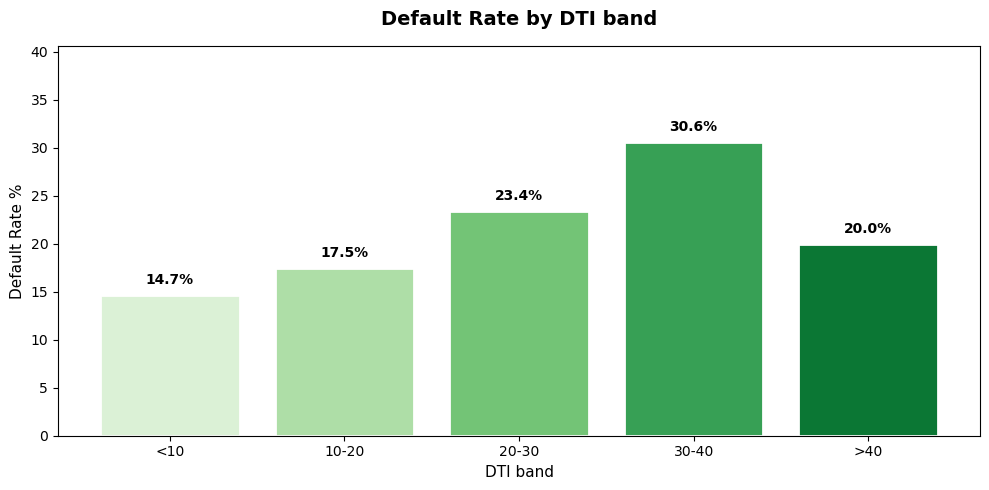

In [37]:
# Create DTI bands

df_clean['dti_band'] = pd.cut(
    df_clean['dti'],
    bins = [0,10,20,30,40,100],
    labels = ['<10','10-20','20-30','30-40','>40']
)

# Default rate by DTI band

dti_analysis = df_clean.groupby('dti_band', observed = True)['default'].agg(
    total_loans = 'count',
    defaults = 'sum'
).reset_index()

dti_analysis['default_rate'] = (dti_analysis['defaults']/dti_analysis['total_loans']*100).round(1)

print("Default rate by DTI band: ")
print("-"*40)
print(dti_analysis.to_string(index = False))

# Visualise

fig, ax = plt.subplots(figsize = (10,5))
bars = ax.bar(
    dti_analysis['dti_band'].astype(str),
    dti_analysis['default_rate'],
    color = sns.color_palette('Greens', n_colors = len(dti_analysis)),
    edgecolor = 'white',
    linewidth = 2
)

ax.set_title('Default Rate by DTI band',
            fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_xlabel('DTI band', fontsize = 11)
ax.set_ylabel('Default Rate %', fontsize = 11)
ax.set_ylim(0, dti_analysis['default_rate'].max() + 10)

for bar, rate in zip(bars, dti_analysis['default_rate']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{rate}%',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold'
    )

plt.tight_layout()
plt.savefig('../data/default_rate_by_dti_band.png', dpi = 300, bbox_inches = 'tight')
plt.show()

**EDA Note: DTI >40 band:**
Only 30 loans with DTI >40 in this sample - insufficient volume 
for reliable rate estimation. Low sample bias suspected due to 
lender rejection of high-DTI applications at origination.
Action: merge >40 into 30-40 band during feature engineering (Phase 3).

### Phase 3 - Feature Engineering and Risk Scorecard

#### Step 1 - Impute remaining Missing Values

7 columns with 1-30% missing data retained from Phase 2. The strategy:
- Numerical columns - median imputation i.e. robust to outliers
- Categorical columns - mode imputation i.e. (most frequest value)

In [41]:
# Identify remaining missing columns

missing_remaining = df_clean.isnull().sum()
missing_remaining = missing_remaining[missing_remaining > 0]

print("Remaining columns with missing data:")
print("-" * 45)
for col, count in missing_remaining.items():
    pct = round(count/len(df_clean)*100, 1)
    dtype = df_clean[col].dtype
    print(f"{col:<35} {count:>5} missing ({pct}%)  [{dtype}]")

Remaining columns with missing data:
---------------------------------------------
emp_title                            2762 missing (6.3%)  [object]
emp_length                           2757 missing (6.3%)  [object]
dti                                     1 missing (0.0%)  [float64]
revol_util                             23 missing (0.1%)  [float64]
bc_open_to_buy                        412 missing (0.9%)  [float64]
bc_util                               438 missing (1.0%)  [float64]
mo_sin_old_il_acct                   1231 missing (2.8%)  [float64]
mths_since_recent_bc                  396 missing (0.9%)  [float64]
mths_since_recent_inq                4515 missing (10.3%)  [float64]
num_tl_120dpd_2m                     2414 missing (5.5%)  [float64]
percent_bc_gt_75                      455 missing (1.0%)  [float64]
dti_band                               17 missing (0.0%)  [category]


#### Step 2 - Impute missing values

Numerical Columns - to be imputed with median

Categorical columns - to be imputed with mode

dti_band - to be rebuilt from dti columns

In [43]:
# Numerical columns - median imputation

numerical_missing = [
    'dti', 'revol_util', 'bc_open_to_buy', 'bc_util',
    'mo_sin_old_il_acct', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'num_tl_120dpd_2m', 'percent_bc_gt_75'
]

for col in numerical_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"{col:<35} imputed with median: {median_val:.2f}")

print()

# Categorical columns - mode imputation

categorical_missing = ['emp_title','emp_length']

for col in categorical_missing:
    mod_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mod_val)
    print(f"{col:<35} imputed with mode: {mod_val}")

print()

# Rebuild dti_band from dti

df_clean['dti_band'] = pd.cut(
    df_clean['dti'],
    bins = [0,10,20,30,40,100],
    labels = ['<10','10-20','20-30','30-40','>40']
)
print("dti_band rebuild from dti column")

# Confirm no missing data remains

remaining  = df_clean.isnull().sum().sum()
print(f"\nTotal missing values remaining: {remaining}")

dti                                 imputed with median: 18.53
revol_util                          imputed with median: 50.90
bc_open_to_buy                      imputed with median: 4833.00
bc_util                             imputed with median: 62.30
mo_sin_old_il_acct                  imputed with median: 129.00
mths_since_recent_bc                imputed with median: 13.00
mths_since_recent_inq               imputed with median: 5.00
num_tl_120dpd_2m                    imputed with median: 0.00
percent_bc_gt_75                    imputed with median: 40.00

emp_title                           imputed with mode: Teacher
emp_length                          imputed with mode: 10+ years

dti_band rebuild from dti column

Total missing values remaining: 16


In [44]:
# Investigate remaining missing values

still_missing = df_clean.isnull().sum()
still_missing = still_missing[still_missing > 0]

print("Columns still missing after imputation:")
print("-" * 45)
for col, count in still_missing.items():
    pct = round(count / len(df_clean) * 100, 2)
    print(f"{col:<35} {count:>5} missing ({pct}%)")

# If dti_band is the culprit — inspect the dti values
if 'dti_band' in still_missing.index:
    print(f"\nDTI values where dti_band is NaN:")
    print(df_clean[df_clean['dti_band'].isnull()]['dti'].describe())

Columns still missing after imputation:
---------------------------------------------
dti_band                               16 missing (0.04%)

DTI values where dti_band is NaN:
count    16.00
mean     77.28
std     249.18
min       0.00
25%       0.00
50%       0.00
75%       0.00
max     999.00
Name: dti, dtype: float64


In [45]:
# Capping extreme dti values - Winsorization
# DTI of 999 is data error - cap at 100

extreme_dti = df_clean[df_clean['dti']>100]
print(f"Rows with DTI > 100: {len(extreme_dti)}")
print(f"DTI values: {extreme_dti['dti'].values}")

#Apply Cap

df_clean['dti'] = df_clean['dti'].clip(upper = 100)

# Rebuild dti_band with corrected bins
# Start at -1 to include DTO = 0

df_clean['dti_band'] = pd.cut(
    df_clean['dti'],
    bins = [-1,10,20,30,40,100],
    labels = ['<10','10-20','20-30','30-40','>40']
)

# Confirm fix

remaining = df_clean['dti_band'].isnull().sum()
print(f"\nMissing dti_band values after fix: {remaining}")
print(f"Total missing values in dataset: {df_clean.isnull().sum().sum()}")  

# Show updated DTI band distribution

print(f"\nDTI band distribution:")
print(df_clean['dti_band'].value_counts().sort_index())

Rows with DTI > 100: 3
DTI values: [999.   137.4  100.09]

Missing dti_band values after fix: 0
Total missing values in dataset: 0

DTI band distribution:
dti_band
<10       7188
10-20    17451
20-30    13971
30-40     5363
>40         33
Name: count, dtype: int64


#### Step 3 — Green / Amber / Red Risk Scorecard

Scoring logic based on three validated risk signals:
- Loan Grade (weight: primary)
- Interest Rate Band (weight: secondary)  
- DTI Band (weight: tertiary)

Tier definitions:
- Green: Grade A-B, DTI <20, Rate <12%
- Amber: Grade C-D, DTI 20-30, Rate 12-20%
- Red:   Grade E-G, DTI >30, Rate >20%

Each signal contributes a score - final tier assigned from total score. 

In [46]:
# Score each signal

# Grade Score (0-3)
grade_score_map = {'A':0, 'B':1, 'C':2, 'D':2, 'E':3, 'F':3, 'G':3}
df_clean['grade_score'] = df_clean['grade'].map(grade_score_map)

#Interest rate score (0-3)
def rate_score(rate):
    if rate < 12:
        return 0
    elif rate < 20:
        return 1
    else:
        return 2

df_clean['rate_score'] = df_clean['int_rate'].apply(rate_score)

# DTI score (0-2)
def dti_score(dti):
    if dti < 20:
        return 0
    elif dti <= 30:
        return 1
    else:
        return 2

df_clean['dti_score'] = df_clean['dti'].apply(dti_score)

# Step 2 - Weighted total score
# Grade carries most weight (x2), rate and dti standard weight

df_clean['risk_score'] = df_clean['grade_score']*2 + df_clean['rate_score'] + df_clean['dti_score']

print("Risk score distribution:")
print(df_clean['risk_score'].value_counts().sort_index())
print(f"\nScore range: {df_clean['risk_score'].min()}" 
        f"to {df_clean['risk_score'].max()}")

Risk score distribution:
risk_score
0     5673
1     2382
2     8767
3     4308
4     2528
5     8367
6     5372
7     3849
8     1458
9     1055
10     247
Name: count, dtype: int64

Score range: 0to 10


Green (0-2):  5673 + 2382 + 8767 = 16822

Amber (3-6):  4308 + 2528 + 8367 + 5372 = 20575

Red   (7-10): 3849 + 1458 + 1055 + 247 = 6609

Green: 16,822 / 44,006 = 38.23%

Amber: 20,575 / 44,006 = 46.75%

Red:    6,609 / 44,006 = 15.02%

In [48]:
# Assign risk tiers from the score

def assign_tier(score):
    if score <= 2:
        return 'Green'
    elif score <= 6:
        return 'Amber'
    else:
        return 'Red'

df_clean['risk_tier'] = df_clean['risk_score'].apply(assign_tier)

# Confirm distribution

tier_counts = df_clean['risk_tier'].value_counts()
tier_pct = (tier_counts / len(df_clean) * 100).round(1)

print("Risk tier distribution:")
print("-"*40)
for  tier in ['Green','Amber','Red']:
    count = tier_counts[tier]
    pct = tier_pct[tier]
    print(f"{tier:<8} {count:>6} loans ({pct}%)")

print(f"\n Total: {len(df_clean):} loans")

# Default Rate by Tier - validation

print("\nDefault rate by Risk tier:")
print("-"*40)

tier_default = df_clean.groupby('risk_tier')['default'].agg(
    total = 'count',
    defaults = 'sum'
).reset_index()

tier_default['default_rate'] = (tier_default['defaults']/tier_default['total']*100).round(1)

for tier in ['Green','Amber','Red']:
    row = tier_default[tier_default['risk_tier'] == tier].iloc[0]
    print(f"{tier:<8} {row['default_rate']}% default rate")

Risk tier distribution:
----------------------------------------
Green     16822 loans (38.2%)
Amber     20575 loans (46.8%)
Red        6609 loans (15.0%)

 Total: 44006 loans

Default rate by Risk tier:
----------------------------------------
Green    8.9% default rate
Amber    23.2% default rate
Red      41.7% default rate


#### Risk Scorecard Visualisation
Three-tier portfolio view — the centrepiece of the dashboard.

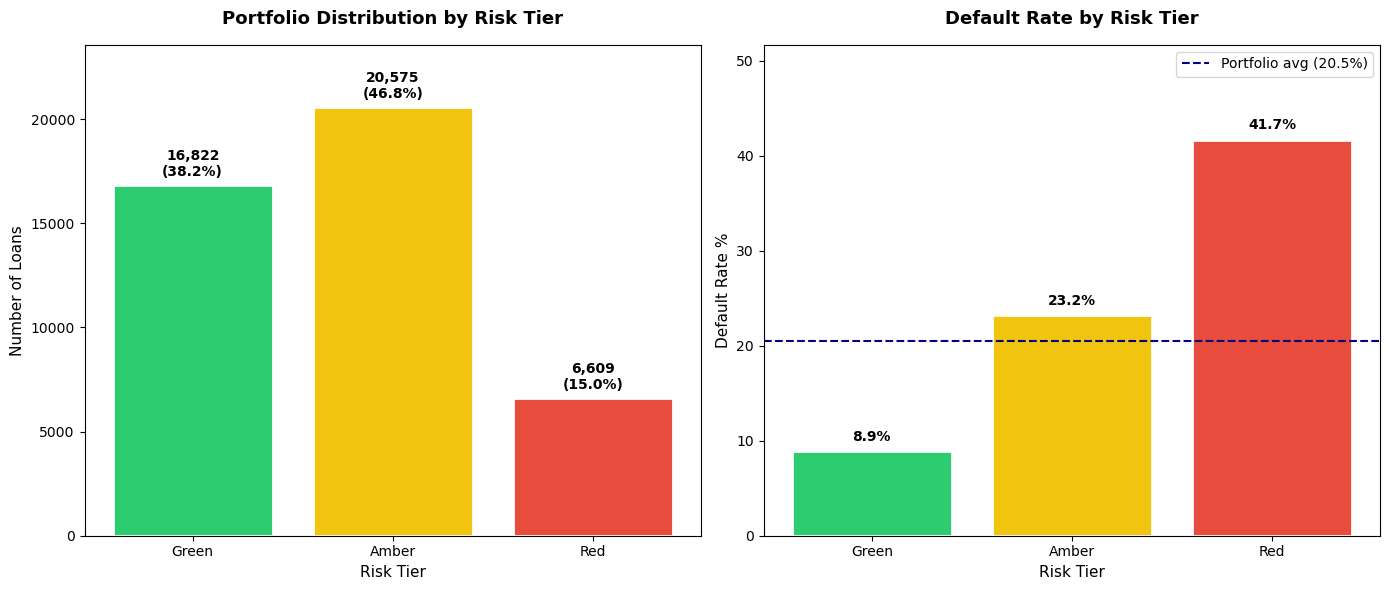

In [62]:
fig, axes = plt.subplots(1,2, figsize = (14,6))

# Chart 1 - POrtfolio distribution by tier

tier_order = ['Green','Amber','Red']
colors = ['#2ecc71', '#f1c40f', '#e74c3c']
counts = [tier_counts[t] for t in tier_order]
pcts = [tier_pct[t] for t in tier_order]

bars = axes[0].bar(
    tier_order,
    counts,
    color = colors,
    edgecolor = 'white',
    linewidth = 2
)

axes[0].set_title('Portfolio Distribution by Risk Tier',
                    fontsize = 13, fontweight = 'bold', pad = 15)
axes[0].set_xlabel('Risk Tier', fontsize=11) 
axes[0].set_ylabel('Number of Loans', fontsize = 11)
axes[0].set_ylim(0, max(counts) + 3000)

for bar, count, pct in zip(bars, counts, pcts):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 300,
        f'{count:,}\n({pct}%)',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold'
    )

# Chart 2 - Default rate by tier

default_rates = [8.9,23.2,41.7]

bars2 = axes[1].bar(
    tier_order,
    default_rates,
    color = colors,
    edgecolor = 'white',
    linewidth = 2
)

axes[1].set_title('Default Rate by Risk Tier',
                    fontsize = 13, fontweight = 'bold', pad = 15)
axes[1].set_ylabel('Default Rate %', fontsize = 11)
axes[1].set_xlabel('Risk Tier', fontsize=11)
axes[1].set_ylim(0, max(default_rates) + 10)

for bar, rate in zip(bars2, default_rates):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{rate}%',
        ha = 'center',
        va = 'bottom',
        fontsize = 10,
        fontweight = 'bold'
    )   

axes[1].axhline(
    y=20.5, color='navy', linestyle='--',
    linewidth=1.5, label='Portfolio avg (20.5%)'
)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('../data/risk_tier_analysis.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [63]:
# Saved cleaned dataset for modelling notebook
df_clean.to_csv('../data/loans_clean.csv', index=False)
print(f"Saved: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

Saved: 44,006 rows, 84 columns
